In [7]:
!pip install kaggle

In [8]:
kaggle = '/content/kaggle.json'

In [12]:
import os

# Ensure the .kaggle directory exists
if not os.path.exists(os.path.expanduser('~/.kaggle')):
    !mkdir ~/.kaggle

# Copy kaggle.json to the correct directory
# Use f-string or os.path.join for robustness, or directly use shell variable expansion
!cp {kaggle} ~/.kaggle/

# Set correct permissions
!chmod 600 ~/.kaggle/kaggle.json

In [14]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
  0% 0.00/66.7M [00:00<?, ?B/s]
100% 66.7M/66.7M [00:00<00:00, 1.29GB/s]


In [15]:
from zipfile import ZipFile

file_name = 'handwritten-digits-0-9.zip'

extract_folder = 'dataset'
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)
    print('Done')

Done


In [16]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [17]:
len(data_0)

2236

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Parameter
BATCH_SIZE = 32
IMG_HEIGHT = 28
IMG_WIDTH = 28
DATA_DIR = '/content/dataset' # Sesuai path hasil ekstrak

# 1. Load Dataset & Split (Training & Validation)
train_ds = tf.keras.utils.image_dataset_from_directory(
  DATA_DIR,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  color_mode='grayscale',
  batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  DATA_DIR,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  color_mode='grayscale',
  batch_size=BATCH_SIZE
)

# 2. Normalisasi (Rescaling 1./255)
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

print("Preprocessing selesai. Data siap digunakan.")

Found 21555 files belonging to 10 classes.
Using 17244 files for training.
Found 21555 files belonging to 10 classes.
Using 4311 files for validation.
Preprocessing selesai. Data siap digunakan.


In [20]:
# --- ARSITEKTUR MODEL MLP ---
model = models.Sequential([
    # Input Layer (Flatten): Mengubah citra 2D (28x28) menjadi vektor 1D (784 pixel)
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),

    # Hidden Layer 1: 128 neuron, aktivasi ReLU
    layers.Dense(128, activation='relu'),

    # Hidden Layer 2 (Opsional): 64 neuron, aktivasi ReLU (agar lebih dalam sedikit)
    layers.Dense(64, activation='relu'),

    # Output Layer: 10 neuron (karena ada digit 0-9), aktivasi Softmax (untuk probabilitas multi-kelas)
    layers.Dense(10, activation='softmax')
])

# Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Tampilkan ringkasan arsitektur
model.summary()

# --- PROSES TRAINING ---
# Melatih model selama 15 epoch
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1242 - loss: 2.3379 - val_accuracy: 0.1594 - val_loss: 2.2081
Epoch 2/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.2099 - loss: 2.1548 - val_accuracy: 0.3057 - val_loss: 2.0136
Epoch 3/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2984 - loss: 1.9875 - val_accuracy: 0.3292 - val_loss: 1.9115
Epoch 4/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.3579 - loss: 1.8540 - val_accuracy: 0.3561 - val_loss: 1.8833
Epoch 5/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3980 - loss: 1.7661 - val_accuracy: 0.4328 - val_loss: 1.7232
Epoch 6/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.4310 - loss: 1.6969 - val_accuracy: 0.4386 - val_loss: 1.6849
Epoch 7/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4450 - loss: 1.6454 - val_accuracy: 0.4669 - val_loss: 1.6285
Epoch 8/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4673 - loss: 1.6020 - val_accu

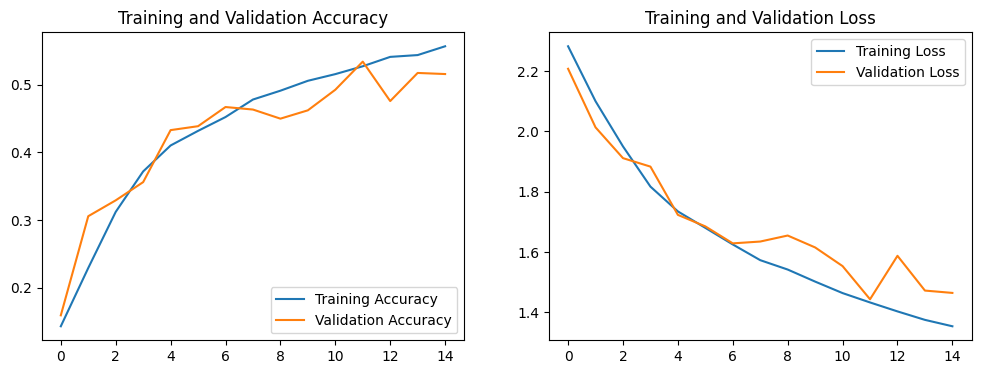

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━

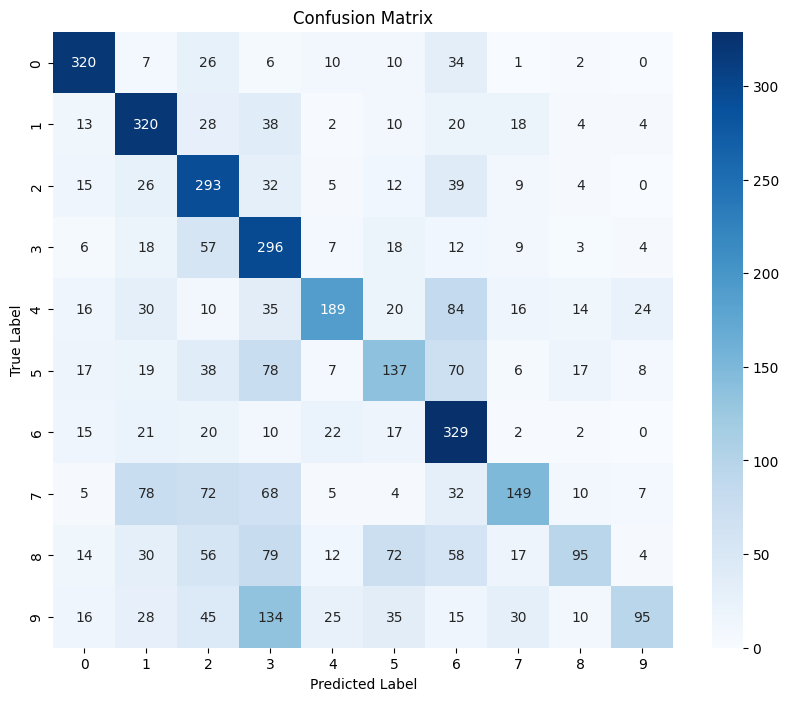

              precision    recall  f1-score   support

           0       0.73      0.77      0.75       416
           1       0.55      0.70      0.62       457
           2       0.45      0.67      0.54       435
           3       0.38      0.69      0.49       430
           4       0.67      0.43      0.52       438
           5       0.41      0.35      0.37       397
           6       0.47      0.75      0.58       438
           7       0.58      0.35      0.43       430
           8       0.59      0.22      0.32       437
           9       0.65      0.22      0.33       433

    accuracy                           0.52      4311
   macro avg       0.55      0.51      0.50      4311
weighted avg       0.55      0.52      0.50      4311



In [21]:
# 1. Plot Grafik Akurasi dan Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# 2. Confusion Matrix & Classification Report
# Ambil true labels dan predicted labels dari validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print Laporan Detail (Precision, Recall, F1-Score)
print(classification_report(y_true, y_pred))